<a href="https://colab.research.google.com/github/Vishalkalal-css/smart-library-inventory-system/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#database system and imports

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

DB_NAME = "smart_library.db"
FINE_PER_DAY = 5      # fine in rupees per late day
LOAN_DAYS = 7         # how many days an item can be kept

conn = sqlite3.connect(DB_NAME)
cur = conn.cursor()

cur.executescript("""
CREATE TABLE IF NOT EXISTS items (
    item_id        INTEGER PRIMARY KEY AUTOINCREMENT,
    item_type      TEXT NOT NULL,          -- 'Book' or 'Equipment'
    name           TEXT NOT NULL,
    author_brand   TEXT,
    category       TEXT,
    total_qty      INTEGER NOT NULL,
    available_qty  INTEGER NOT NULL
);

CREATE TABLE IF NOT EXISTS students (
    student_id  INTEGER PRIMARY KEY AUTOINCREMENT,
    name        TEXT NOT NULL,
    department  TEXT,
    email       TEXT
);

CREATE TABLE IF NOT EXISTS issues (
    issue_id     INTEGER PRIMARY KEY AUTOINCREMENT,
    item_id      INTEGER NOT NULL,
    student_id   INTEGER NOT NULL,
    issue_date   TEXT NOT NULL,
    due_date     TEXT NOT NULL,
    return_date  TEXT,
    fine         INTEGER DEFAULT 0,
    FOREIGN KEY (item_id) REFERENCES items(item_id),
    FOREIGN KEY (student_id) REFERENCES students(student_id)
);
""")
conn.commit()

#Function for add items and students

In [6]:
def add_item(item_type, name, author_brand, category, qty):
    cur.execute(
        "INSERT INTO items (item_type, name, author_brand, category, total_qty, available_qty) VALUES (?,?,?,?,?,?)",
        (item_type, name, author_brand, category, qty, qty)
    )
    conn.commit()
    print(f"Added {item_type}: {name} (qty {qty})")

def add_student(name, department, email):
    cur.execute(
        "INSERT INTO students (name, department, email) VALUES (?,?,?)",
        (name, department, email)
    )
    conn.commit()
    print(f"Student added: {name}")

#adding some semple data

In [7]:
add_item("Book", "Python Crash Course", "Eric Matthes", "Programming", 3)
add_item("Book", "Data Structures Made Easy", "Narasimha Karumanchi", "Computer Science", 2)
add_item("Book", "Engineering Mathematics", "B.S. Grewal", "Mathematics", 4)
add_item("Equipment", "Scientific Calculator", "Casio", "Calculator", 5)
add_item("Equipment", "Arduino Kit", "Arduino", "Electronics", 2)
add_item("Equipment", "Laptop", "Dell", "Computer", 1)

add_student("Aarav Sharma", "Computer Science", "aarav@college.edu")
add_student("Priya Verma", "Electronics", "priya@college.edu")
add_student("Rohan Meena", "Mechanical", "rohan@college.edu")

Added Book: Python Crash Course (qty 3)
Added Book: Data Structures Made Easy (qty 2)
Added Book: Engineering Mathematics (qty 4)
Added Equipment: Scientific Calculator (qty 5)
Added Equipment: Arduino Kit (qty 2)
Added Equipment: Laptop (qty 1)
Student added: Aarav Sharma
Student added: Priya Verma
Student added: Rohan Meena


In [8]:
def show_items():
    return pd.read_sql_query("SELECT * FROM items", conn)

def show_students():
    return pd.read_sql_query("SELECT * FROM students", conn)

show_items()

,item_id,item_type,name,author_brand,category,total_qty,available_qty
0,1,Book,Python Crash Course,Eric Matthes,Programming,3,3
1,2,Book,Data Structures Made Easy,Narasimha Karumanchi,Computer Science,2,2
2,3,Book,Engineering Mathematics,B.S. Grewal,Mathematics,4,4
3,4,Equipment,Scientific Calculator,Casio,Calculator,5,5
4,5,Equipment,Arduino Kit,Arduino,Electronics,2,2
5,6,Equipment,Laptop,Dell,Computer,1,1


In [9]:
show_students()

,student_id,name,department,email
0,1,Aarav Sharma,Computer Science,aarav@college.edu
1,2,Priya Verma,Electronics,priya@college.edu
2,3,Rohan Meena,Mechanical,rohan@college.edu


#issue a item to a student

In [10]:
def issue_item(item_id, student_id):
    # check item exists and is available
    cur.execute("SELECT name, available_qty FROM items WHERE item_id = ?", (item_id,))
    item = cur.fetchone()
    if item is None:
        print("Item not found.")
        return

    cur.execute("SELECT name FROM students WHERE student_id = ?", (student_id,))
    student = cur.fetchone()
    if student is None:
        print("Student not found.")
        return

    if item[1] <= 0:
        print(f"Sorry, '{item[0]}' is not available right now.")
        return

    today = datetime.now()
    due = today + timedelta(days=LOAN_DAYS)

    cur.execute(
        "INSERT INTO issues (item_id, student_id, issue_date, due_date) VALUES (?,?,?,?)",
        (item_id, student_id, today.strftime("%Y-%m-%d"), due.strftime("%Y-%m-%d"))
    )
    cur.execute("UPDATE items SET available_qty = available_qty - 1 WHERE item_id = ?", (item_id,))
    conn.commit()
    print(f"'{item[0]}' issued to {student[0]}. Due date: {due.strftime('%Y-%m-%d')}")

In [12]:
issue_item(1, 1)   # Python Crash Course -> Aarav
issue_item(4, 2)   # Calculator -> Priya
issue_item(6, 3)   # Laptop -> Rohan
issue_item(6, 1)   # Laptop again -> should say not available

'Python Crash Course' issued to Aarav Sharma. Due date: 2026-10-11
'Scientific Calculator' issued to Priya Verma. Due date: 2026-10-11
Sorry, 'Laptop' is not available right now.
Sorry, 'Laptop' is not available right now.


#return item with fine autometiclly

In [15]:
def return_item(issue_id, return_date=None):
    cur.execute("SELECT item_id, due_date, return_date FROM issues WHERE issue_id = ?", (issue_id,))
    row = cur.fetchone()
    if row is None:
        print("Issue record not found.")
        return
    if row[2] is not None:
        print("This item was already returned.")
        return

    item_id, due_date, _ = row
    returned = datetime.strptime(return_date, "%Y-%m-%d") if return_date else datetime.now()
    due = datetime.strptime(due_date, "%Y-%m-%d")

    late_days = max((returned - due).days, 0)
    fine = late_days * FINE_PER_DAY

    cur.execute("UPDATE issues SET return_date = ?, fine = ? WHERE issue_id = ?",
                (returned.strftime("%Y-%m-%d"), fine, issue_id))
    cur.execute("UPDATE items SET available_qty = available_qty + 1 WHERE item_id = ?", (item_id,))
    conn.commit()

    if fine > 0:
        print(f"Returned {late_days} day(s) late. Fine: Rs.{fine}")
    else:
        print("Returned on time. No fine.")

In [20]:
return_item(1)

# Test the fine by pretending the return happens 10 days from now:
future = (datetime.now() + timedelta(days=15)).strftime("%Y-%m-%d")
return_item(4, future)

This item was already returned.
Returned 8 day(s) late. Fine: Rs.40


#searching system

In [21]:
def search_items(keyword):
    query = """
    SELECT item_id, item_type, name, author_brand, category, available_qty
    FROM items
    WHERE name LIKE ? OR author_brand LIKE ? OR category LIKE ?
    """
    kw = f"%{keyword}%"
    return pd.read_sql_query(query, conn, params=(kw, kw, kw))

search_items("python")

,item_id,item_type,name,author_brand,category,available_qty
0,1,Book,Python Crash Course,Eric Matthes,Programming,3


#reports

In [22]:
def currently_issued():
    query = """
    SELECT i.issue_id, s.name AS student, it.name AS item, i.issue_date, i.due_date
    FROM issues i
    JOIN students s ON i.student_id = s.student_id
    JOIN items it ON i.item_id = it.item_id
    WHERE i.return_date IS NULL
    """
    return pd.read_sql_query(query, conn)

currently_issued()

,issue_id,student,item,issue_date,due_date
0,3,Rohan Meena,Laptop,2026-10-04,2026-10-11
1,5,Priya Verma,Scientific Calculator,2026-10-04,2026-10-11


#overdue items

In [23]:
def overdue_items():
    today = datetime.now().strftime("%Y-%m-%d")
    query = """
    SELECT i.issue_id, s.name AS student, s.email, it.name AS item, i.due_date
    FROM issues i
    JOIN students s ON i.student_id = s.student_id
    JOIN items it ON i.item_id = it.item_id
    WHERE i.return_date IS NULL AND i.due_date < ?
    """
    return pd.read_sql_query(query, conn, params=(today,))

overdue_items()

,issue_id,student,email,item,due_date


#stock alert at low

In [24]:
def low_stock(limit=1):
    return pd.read_sql_query(
        "SELECT item_id, name, available_qty FROM items WHERE available_qty <= ?",
        conn, params=(limit,)
    )

low_stock()

,item_id,name,available_qty
0,6,Laptop,0


fine collection


In [25]:
pd.read_sql_query("SELECT SUM(fine) AS total_fines FROM issues", conn)

,total_fines
0,55


#charts

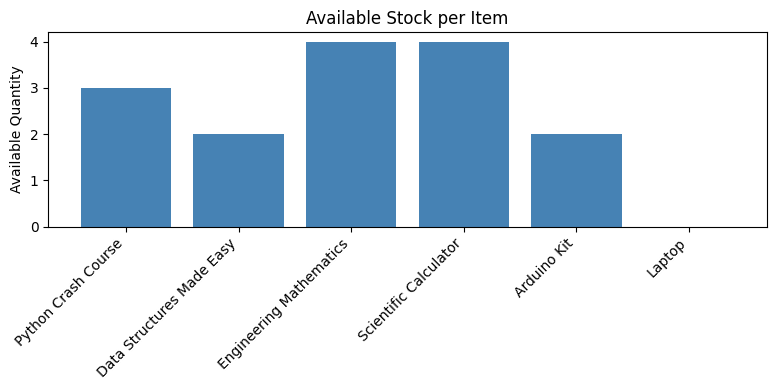

In [26]:
df = show_items()

plt.figure(figsize=(8, 4))
plt.bar(df["name"], df["available_qty"], color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.title("Available Stock per Item")
plt.ylabel("Available Quantity")
plt.tight_layout()
plt.show()

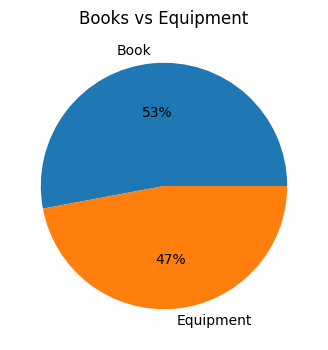

In [27]:
type_count = df.groupby("item_type")["total_qty"].sum()
type_count.plot(kind="pie", autopct="%1.0f%%", figsize=(4, 4), title="Books vs Equipment")
plt.ylabel("")
plt.show()

#Menu

In [28]:
def menu():
    while True:
        print("\n=== SMART LIBRARY & INVENTORY ===")
        print("1. Show items   2. Show students   3. Issue item")
        print("4. Return item  5. Search           6. Overdue list")
        print("0. Exit")
        choice = input("Enter choice: ")

        if choice == "1":
            display(show_items())
        elif choice == "2":
            display(show_students())
        elif choice == "3":
            issue_item(int(input("Item ID: ")), int(input("Student ID: ")))
        elif choice == "4":
            return_item(int(input("Issue ID: ")))
        elif choice == "5":
            display(search_items(input("Search keyword: ")))
        elif choice == "6":
            display(overdue_items())
        elif choice == "0":
            print("Goodbye!")
            break
        else:
            print("Invalid choice, try again.")

menu()


=== SMART LIBRARY & INVENTORY ===
1. Show items   2. Show students   3. Issue item
4. Return item  5. Search           6. Overdue list
0. Exit
Enter choice: 1


,item_id,item_type,name,author_brand,category,total_qty,available_qty
0,1,Book,Python Crash Course,Eric Matthes,Programming,3,3
1,2,Book,Data Structures Made Easy,Narasimha Karumanchi,Computer Science,2,2
2,3,Book,Engineering Mathematics,B.S. Grewal,Mathematics,4,4
3,4,Equipment,Scientific Calculator,Casio,Calculator,5,4
4,5,Equipment,Arduino Kit,Arduino,Electronics,2,2
5,6,Equipment,Laptop,Dell,Computer,1,0



=== SMART LIBRARY & INVENTORY ===
1. Show items   2. Show students   3. Issue item
4. Return item  5. Search           6. Overdue list
0. Exit
Enter choice: 2


,student_id,name,department,email
0,1,Aarav Sharma,Computer Science,aarav@college.edu
1,2,Priya Verma,Electronics,priya@college.edu
2,3,Rohan Meena,Mechanical,rohan@college.edu



=== SMART LIBRARY & INVENTORY ===
1. Show items   2. Show students   3. Issue item
4. Return item  5. Search           6. Overdue list
0. Exit
Enter choice: 3
Item ID: 123
Student ID: 1234
Item not found.

=== SMART LIBRARY & INVENTORY ===
1. Show items   2. Show students   3. Issue item
4. Return item  5. Search           6. Overdue list
0. Exit
Enter choice: 0
Goodbye!
